###   Gmail-Triggered LangGraph Agent
##### Reads unread emails, extracts travel queries, searches the web, and returns AI-generated answers.

##### Author  : Debsubhra Chakraborty
##### Stack   : LangGraph · Groq (Llama 3.3) · DuckDuckGo · Redis Cloud
##### Cost    : Zero — all free tier services

#### Imports

In [ ]:
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from google.auth.transport.requests import Request
from langchain_google_community.gmail.utils import build_gmail_service
from langchain_google_community.gmail.utils import build_resource_service
import os
from langchain_google_community.gmail.search import GmailSearch
import base64
from pypdf import PdfReader
from docx import Document
from IPython.display import Image,display
from langgraph.graph import StateGraph, END
import redis
import hashlib
from typing import TypedDict, Optional
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage
from ddgs import DDGS

from dotenv import load_dotenv
load_dotenv()



##### GMAIL AUTHENTICATION
##### Uses OAuth2 to authenticate with Gmail API.
##### On first run: opens browser for consent.
##### On subsequent runs: uses saved token.json silently.

In [ ]:
scopes=["https://mail.google.com/"]

def get_credentials():

    creds = None

    if os.path.exists("token.json"):    
        creds = Credentials.from_authorized_user_file("token.json",scopes)
    
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            flow = InstalledAppFlow.from_client_secrets_file(
                "credentials.json",scopes
            )
            creds = flow.run_local_server(port=0)
        
        with open("token.json","w") as f:
            f.write(creds.to_json())
    
    return creds

# Build Gmail API service object
credentials = get_credentials()
service = build_resource_service(credentials=credentials)
print("built gmail service successfully")



##### EMAIL READING. Fetches unread emails from Gmail Primary inbox.

In [41]:
def get_email_body(service, msg_id):
    msg = service.users().messages().get(
        userId='me', id=msg_id, format='full'
    ).execute()

    subject, sender, body = "", "", ""

    for h in msg['payload'].get('headers', []):
        if h['name'] == 'Subject':
            subject = h['value']
        if h['name'] == 'From':
            sender = h['value']

    payload = msg['payload']

    def extract_text_from_parts(parts):
        for part in parts:
            if part['mimeType'] == 'text/plain':
                data = part['body'].get('data', '')
                if data:
                    return base64.urlsafe_b64decode(data).decode('utf-8')
            # handle nested parts (multipart/alternative etc.)
            if 'parts' in part:
                result = extract_text_from_parts(part['parts'])
                if result:
                    return result
        return ""

    if 'parts' in payload:
        body = extract_text_from_parts(payload['parts'])
    else:
        data = payload['body'].get('data', '')
        if data:
            body = base64.urlsafe_b64decode(data).decode('utf-8')

    # Clean up escape characters
    body = body.replace('\r\n', '\n').replace('\r', '\n').strip()

    return {"id": msg_id, "subject": subject, "from": sender, "body": body}

##### Downloads PDF/DOCX attachments if present.

In [42]:
def download_attachments(service, msg_id, output_dir="./attachments"):
    os.makedirs(output_dir, exist_ok=True)

    msg = service.users().messages().get(
        userId='me', id=msg_id, format='full'
    ).execute()

    attachments = []

    def process_parts(parts):
        for part in parts:
            filename = part.get('filename')
            if filename:
                att_id = part['body'].get('attachmentId')
                if att_id:
                    att = service.users().messages().attachments().get(
                        userId='me', messageId=msg_id, id=att_id
                    ).execute()
                    data = base64.urlsafe_b64decode(
                        att['data'].encode('UTF-8')
                    )
                    filepath = os.path.join(output_dir, filename)
                    with open(filepath, 'wb') as f:
                        f.write(data)
                    attachments.append(filepath)
                    print(f"  Downloaded: {filename}")
            
            if 'parts' in part:
                process_parts(part['parts'])

    process_parts(msg['payload'].get('parts', []))
    return attachments

##### Attachment parsing

In [43]:
def parse_attachment(filepath):
    text = ""

    if filepath.endswith(".pdf"):
        reader = PdfReader(filepath)
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:
                text += extracted + "\n"

    elif filepath.endswith(".docx"):
        doc = Document(filepath)
        for para in doc.paragraphs:
            text += para.text + "\n"

    elif filepath.endswith(".txt"):
        with open(filepath, 'r') as f:
            text = f.read()

    else:
        print(f"  Skipping unsupported file: {filepath}")

    return text.strip()

##### Process all unread email, extract content and download (and parse) attachment

In [ ]:
def process_all_unread_emails(service, max_results=20):
    print("Fetching unread emails from Primary inbox...\n")

    results = service.users().messages().list(
        userId='me',
        labelIds=['INBOX', 'CATEGORY_PERSONAL'],
        q='is:unread',
        maxResults=max_results
    ).execute()

    messages = results.get('messages', [])

    if not messages:
        print("No unread emails found.")
        return []

    print(f"Found {len(messages)} unread email(s)\n")
    all_processed = []

    for msg in messages:
        msg_id = msg['id']
        print(f"Processing: {msg_id}")

        # Step 1: Get email body
        email_data = get_email_body(service, msg_id)
        print(f"  From   : {email_data['from']}")
        print(f"  Subject: {email_data['subject']}")

        # Step 2: Download attachments if any
        attachment_files = download_attachments(service, msg_id)

        # Step 3: Parse attachments
        attachment_texts = []
        if attachment_files:
            for filepath in attachment_files:
                parsed = parse_attachment(filepath)
                if parsed:
                    attachment_texts.append(f"[{os.path.basename(filepath)}]:\n{parsed}")
        else:
            print("  No attachments found.")

        # Step 4: Combine into one content block
        full_content = f"""
            FROM: {email_data['from']}
            SUBJECT: {email_data['subject']}
            BODY:
            {email_data['body']}
            ATTACHMENTS:
            {chr(10).join(attachment_texts) if attachment_texts else 'None'}
            """.strip()

        all_processed.append({
            "msg_id": msg_id,
            "subject": email_data['subject'],
            "from": email_data['from'],
            "full_content": full_content
        })

        print(f"  Done.\n{'─'*50}")

    return all_processed

processed_emails = process_all_unread_emails(service)

##### LANGGRAPH STATE :
##### Shared state object passed between all graph nodes. Each node reads from and writes to this state.

In [45]:
class AgentState(TypedDict):
    # email data
    raw_email_content: str              # full email + attachment text

    # extracted query
    extracted_query: str                # e.g. "chepest hotel in Manali"

    # Cache
    cache_key: str                      # hashed query key
    cache_hit: bool                     # true if found in redis

    # search & llm
    search_results: str                 # duckduckgo results
    llm_response: str                   # Groq LLM response

    # final
    final_answer: str                   # formatted response


##### REDIS CACHE SETUP: 
##### Uses Redis Cloud free tier for query result caching. Prevents redundant LLM calls for repeated queries. TTL: 24 hours

In [46]:
r = redis.Redis(
    host=os.getenv("REDIS_HOST"),
    port=int(os.getenv("REDIS_PORT")),
    username=os.getenv("REDIS_USERNAME"),
    password=os.getenv("REDIS_PASSWORD"),
    decode_responses=True,
    ssl=False
)

def make_cache_key(query: str) -> str:
    normalized = query.lower().strip()
    return f"query:{hashlib.md5(normalized.encode()).hexdigest()}"

# Test connection
try:
    r.ping()
    print("Redis connected successfully")
except Exception as e:
    print(f"Redis connection failed: {e}")



Redis connected successfully


### email parser node

In [47]:
def email_parser_node(state: AgentState) -> AgentState:
    """
    Receives raw email content (already extracted in previous step).
    Just passes it through — your existing Gmail code feeds this.
    """
    print(f"[EMAIL PARSER] Content length: {len(state['raw_email_content'])} chars")
    return state

##### query extractor node

In [48]:
llm = ChatGroq(model="llama-3.3-70b-versatile",temperature=0)

def query_extractor_node(state: AgentState) -> AgentState:
    """
    Use LLM to extract the core question from the email content.
    """

    prompt = [
        SystemMessage(content="""You are a query extractor.
                                 Extract the core question or information request from the email content.
                                 Return ONLY the query as a short, clean sentence.
                                 Examples:
                                 - "cheapest hotel in Manali under 2000 rupees"
                                 - "best street food in Chennai"
                                 - "budget flights from Kolkata to Delhi"
                                 Do NOT return any explanation. Just the query."""),
        HumanMessage(content=state['raw_email_content'])
    ]

    response = llm.invoke(prompt)
    extracted_query = response.content.strip()

    print(f"[QUERY EXTRACTOR] Extracted: {extracted_query}")

    return {
        **state,
        "extracted_query": extracted_query,
        "cache_key": make_cache_key(extracted_query)
    }

##### cache check node

In [49]:
def cache_check_node(state: AgentState) -> AgentState:
    """
    Checks Redis for a cached answer to this query.
    Sets cache_hit = True if found.
    """
    print(f"[CACHE CHECK] Checking key: {state['cache_key']}")

    cached = r.get(state['cache_key'])

    if cached:
        print("[CACHE CHECK] HIT — skipping LLM and search")
        return {
            **state,
            "cache_hit": True,
            "final_answer": cached
        }
    else:
        print("[CACHE CHECK] MISS — proceeding to web search")
        return {
            **state,
            "cache_hit": False
        }


def route_after_cache(state: AgentState) -> str:
    """
    Conditional edge — decides next node based on cache hit/miss.
    """
    if state.get("cache_hit"):
        return "response_node"
    return "web_search_node"

##### web search node

In [50]:
import requests
from bs4 import BeautifulSoup
from ddgs import DDGS

def clean_query_for_search(query: str) -> str:
    """
    Make query search-friendly:
    - Remove ₹ symbol (causes issues)
    - Replace 'budget' with 'cheap' (avoids news results)
    - Keep it short and punchy
    """
    query = query.replace('₹', 'INR')
    query = query.replace('budget', 'cheap')
    query = query.strip()
    return query

def fetch_page_content(url: str, max_chars: int = 2000) -> str:
    """Fetch actual page text from a URL"""
    try:
        headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"}
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Remove scripts and styles
        for tag in soup(['script', 'style', 'nav', 'footer']):
            tag.decompose()

        text = soup.get_text(separator=' ', strip=True)
        # Return first max_chars characters
        return text[:max_chars]
    except Exception as e:
        return ""


def web_search_node(state: AgentState) -> AgentState:
    raw_query = state['extracted_query']
    search_query = clean_query_for_search(raw_query)

    print(f"[WEB SEARCH] Original : {raw_query}")
    print(f"[WEB SEARCH] Searching: {search_query}")

    results_text = ""

    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(
                search_query,
                max_results=5,
                region='in-en'
            ))

            if not results:
                # Fallback simpler query
                place = search_query.split('in')[-1].strip()
                results = list(ddgs.text(
                    f"cheap hotels {place} price list",
                    max_results=5,
                    region='in-en'
                ))

            print(f"[WEB SEARCH] Got {len(results)} results")

            for i, r_item in enumerate(results):
                url = r_item.get('href', '')
                snippet = r_item.get('body', '')
                title = r_item.get('title', '')

                # Try fetching page content for first 2 results only
                page_content = ""
                if i < 2 and url:
                    print(f"[WEB SEARCH] Fetching content from: {url}")
                    page_content = fetch_page_content(url)

                results_text += f"\nResult {i+1}:\n"
                results_text += f"Title  : {title}\n"
                results_text += f"Snippet: {snippet}\n"
                results_text += f"URL    : {url}\n"
                if page_content:
                    results_text += f"Content: {page_content}\n"

    except Exception as e:
        print(f"[WEB SEARCH] Error: {e}")
        results_text = "Search failed."

    return {**state, "search_results": results_text}

##### LLM response generator node

In [51]:
def llm_node(state: AgentState) -> AgentState:
    print("[LLM] Generating answer from search results...")

    messages = [
        SystemMessage(content="""You are a helpful travel assistant for Indian travelers.
You will receive search results including page content from travel websites.
Extract and list:
- Hotel name
- Price per night in rupees
- Location/area in the city
- Any special features (WiFi, breakfast, rating)

Format as a numbered list. Be specific.
If no hotel data found in content, say so clearly and provide the URLs."""),

        HumanMessage(content=f"""
Question: {state['extracted_query']}

Search Results and Page Content:
{state['search_results']}

List the hotels with prices found in the above content.
""")
    ]

    response = llm.invoke(messages)
    llm_response = response.content.strip()
    print(f"[LLM] Response generated ({len(llm_response)} chars)")

    return {**state, "llm_response": llm_response}

##### Cache write node

In [52]:
CACHE_TTL_SECONDS = 86400  # 24 hours

def cache_write_node(state: AgentState) -> AgentState:
    """
    Writes LLM response to Redis with 24h TTL.
    """
    print(f"[CACHE WRITE] Storing result for key: {state['cache_key']}")

    r.setex(
        name=state['cache_key'],
        time=CACHE_TTL_SECONDS,
        value=state['llm_response']
    )

    print("[CACHE WRITE] Stored successfully")

    return {
        **state,
        "final_answer": state['llm_response']
    }

##### Response formatter node

In [53]:
def response_node(state: AgentState) -> AgentState:
    """
    Formats the final answer for output.
    In production: send this as Gmail reply.
    """
    print("\n" + "="*60)
    print("FINAL ANSWER:")
    print("="*60)
    print(f"Query  : {state['extracted_query']}")
    print(f"Source : {'Cache' if state.get('cache_hit') else 'Live Search + LLM'}")
    print(f"Answer :\n{state['final_answer']}")
    print("="*60)

    return state

##### BUILD LANGGRAPH : Wires all nodes together with edges and conditional routing.

In [54]:
def build_agent():
    graph = StateGraph(AgentState)

    # Add all nodes
    graph.add_node("email_parser_node",   email_parser_node)
    graph.add_node("query_extractor_node", query_extractor_node)
    graph.add_node("cache_check_node",    cache_check_node)
    graph.add_node("web_search_node",     web_search_node)
    graph.add_node("llm_node",            llm_node)
    graph.add_node("cache_write_node",    cache_write_node)
    graph.add_node("response_node",       response_node)

    # Define flow
    graph.set_entry_point("email_parser_node")
    graph.add_edge("email_parser_node",    "query_extractor_node")
    graph.add_edge("query_extractor_node", "cache_check_node")

    # Conditional edge — cache hit or miss
    graph.add_conditional_edges(
        "cache_check_node",
        route_after_cache,
        {
            "response_node":  "response_node",
            "web_search_node": "web_search_node"
        }
    )

    graph.add_edge("web_search_node",  "llm_node")
    graph.add_edge("llm_node",         "cache_write_node")
    graph.add_edge("cache_write_node", "response_node")
    graph.add_edge("response_node",    END)

    return graph.compile()

agent = build_agent()
print("LangGraph agent compiled successfully")

LangGraph agent compiled successfully


##### RUN AGENT: Processes all unread emails through the agent pipeline. Writes full output to agent_output.txt to avoid truncation.

In [ ]:
for email in processed_emails:
    initial_state: AgentState = {
        "raw_email_content": email['full_content'],
        "extracted_query": "",
        "cache_key": "",
        "cache_hit": False,
        "search_results": "",
        "llm_response": "",
        "final_answer": ""
    }
    result = agent.invoke(initial_state)
    
    # Print full answer without truncation
    print("\n" + "="*60)
    print("SUBJECT :", email['subject'])
    print("QUERY   :", result['extracted_query'])
    print("SOURCE  :", "Cache" if result['cache_hit'] else "Live Search + LLM")
    print("="*60)
    print(result['final_answer'])
    print("="*60 + "\n")

##### Visualize graph

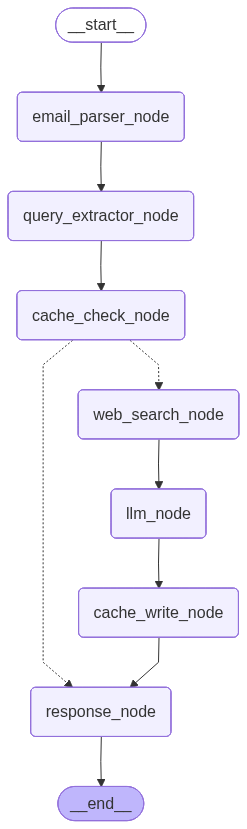

In [56]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    pass
